<a href="https://colab.research.google.com/github/juhsylvabb-ops/Olist_Analysis/blob/main/Relatorio_Final/olist_relatorio_final__VF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style='background:#131D4F;padding:40px;border-radius:12px;text-align:center'>
<h1 style='color:white;font-size:2.2em;margin:0'>Olist E-commerce</h1>
<h2 style='color:#8ECFC9;font-size:1.4em;margin:10px 0 0 0'>Análise Exploratória de Dados — Relatório Executivo</h2>
<p style='color:#aaa;margin:15px 0 0 0'>Brazilian E-Commerce Public Dataset by Olist &nbsp;|&nbsp; Período: Set/2016 – Ago/2018</p>
<p style='color:#aaa;margin:5px 0 0 0'>Tech Challenge · Fase 1 · POSTECH DTAT · JULIANA BRITO · RM374564 </p>
</div>

---
## 1. Contexto do Negócio

A **Olist** é uma plataforma brasileira de e-commerce que conecta pequenos e médios lojistas a grandes marketplaces (Americanas, Shopee, Mercado Livre, entre outros), funcionando como um intermediário tecnológico que simplifica a operação para os vendedores.

O dataset analisado cobre **2 anos de operação** (setembro de 2016 a agosto de 2018) e é composto por **9 tabelas relacionais** contendo informações de pedidos, clientes, produtos, vendedores, pagamentos, avaliações e geolocalização.


### Estrutura da Base

| Tabela | Registros |
|---|---|
| Pedidos | 99.441 |
| Clientes | 99.441 |
| Itens de Pedido | 112.650 |
| Pagamentos | 103.886 |
| Avaliações | 99.224 |
| Produtos | 32.951 |
| Vendedores | 3.095 |
| Geolocalização | 1.000.163 |
| Tradução de Categorias | 71 |

In [1]:
# @title
# ============================================================
# CÉLULA 1 — Preparar arquivos
# ============================================================
import shutil, zipfile, os, glob

os.makedirs('/content/olist', exist_ok=True)

for arquivo in glob.glob('/content/*.zip'):
    with zipfile.ZipFile(arquivo, 'r') as z:
        z.extractall('/content/olist')

for arquivo in glob.glob('/content/*.csv'):
    nome = os.path.basename(arquivo)
    destino = f'/content/olist/{nome}'
    if not os.path.exists(destino):
        shutil.copy(arquivo, destino)

arquivos = [f for f in os.listdir('/content/olist') if f.endswith('.csv')]
print(f'Total de arquivos encontrados: {len(arquivos)}')
for f in sorted(arquivos):
    print(f'  {f}')

Total de arquivos encontrados: 9
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


In [2]:
# @title
# ============================================================
# CÉLULA 2 — Importar bibliotecas e paleta de cores
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Paleta oficial Olist
AZUL      = '#2255E8'
AZUL_DARK = '#131D4F'
VERDE     = '#6B8C3E'
MENTA     = '#8ECFC9'
VERMELHO  = '#E8451E'
ROSA      = '#F0A0C0'
LARANJA   = '#F5A623'

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
print('Ambiente configurado!')

Ambiente configurado!


In [3]:
# @title
# ============================================================
# CÉLULA 3 — Carregar e unificar a base
# ============================================================
CAMINHO = '/content/olist/'

clientes   = pd.read_csv(CAMINHO + 'olist_customers_dataset.csv')
pedidos    = pd.read_csv(CAMINHO + 'olist_orders_dataset.csv')
itens      = pd.read_csv(CAMINHO + 'olist_order_items_dataset.csv')
pagamentos = pd.read_csv(CAMINHO + 'olist_order_payments_dataset.csv')
reviews    = pd.read_csv(CAMINHO + 'olist_order_reviews_dataset.csv')
produtos   = pd.read_csv(CAMINHO + 'olist_products_dataset.csv')
vendedores = pd.read_csv(CAMINHO + 'olist_sellers_dataset.csv')
geo        = pd.read_csv(CAMINHO + 'olist_geolocation_dataset.csv')
categorias = pd.read_csv(CAMINHO + 'product_category_name_translation.csv')

# Conversão de datas
cols_data = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in cols_data:
    pedidos[col] = pd.to_datetime(pedidos[col])

produtos['product_category_name'] = produtos['product_category_name'].fillna('sem_categoria')
geo_unico = geo.drop_duplicates(subset='geolocation_zip_code_prefix')

# Base unificada
base = (
    itens
    .merge(pedidos,    on='order_id',             how='left')
    .merge(clientes,   on='customer_id',           how='left')
    .merge(produtos,   on='product_id',            how='left')
    .merge(categorias, on='product_category_name', how='left')
    .merge(vendedores, on='seller_id',             how='left')
    .merge(pagamentos, on='order_id',              how='left')
    .merge(reviews[['order_id','review_score','review_comment_title',
                    'review_comment_message']], on='order_id', how='left')
    .merge(geo_unico.rename(columns={
               'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
               'geolocation_lat': 'customer_lat',
               'geolocation_lng': 'customer_lng'})
           [['customer_zip_code_prefix','customer_lat','customer_lng']],
           on='customer_zip_code_prefix', how='left')
)

base['order_purchase_timestamp']      = pd.to_datetime(base['order_purchase_timestamp'])
base['order_delivered_customer_date'] = pd.to_datetime(base['order_delivered_customer_date'])
base['order_estimated_delivery_date'] = pd.to_datetime(base['order_estimated_delivery_date'])
base['ano']     = base['order_purchase_timestamp'].dt.year
base['mes']     = base['order_purchase_timestamp'].dt.month
base['ano_mes'] = base['order_purchase_timestamp'].dt.to_period('M')

print(f'Base unificada: {len(base):,} linhas x {base.shape[1]} colunas')
print(f'Periodo: {base["order_purchase_timestamp"].min().date()} a {base["order_purchase_timestamp"].max().date()}')

Base unificada: 118,310 linhas x 42 colunas
Periodo: 2016-09-04 a 2018-09-03


---
## 2. Visão Executiva — KPIs Gerais

Nos dois anos analisados, a Olist consolidou uma operação relevante no e-commerce brasileiro. Os números abaixo traduzem o tamanho e a saúde do negócio no período:

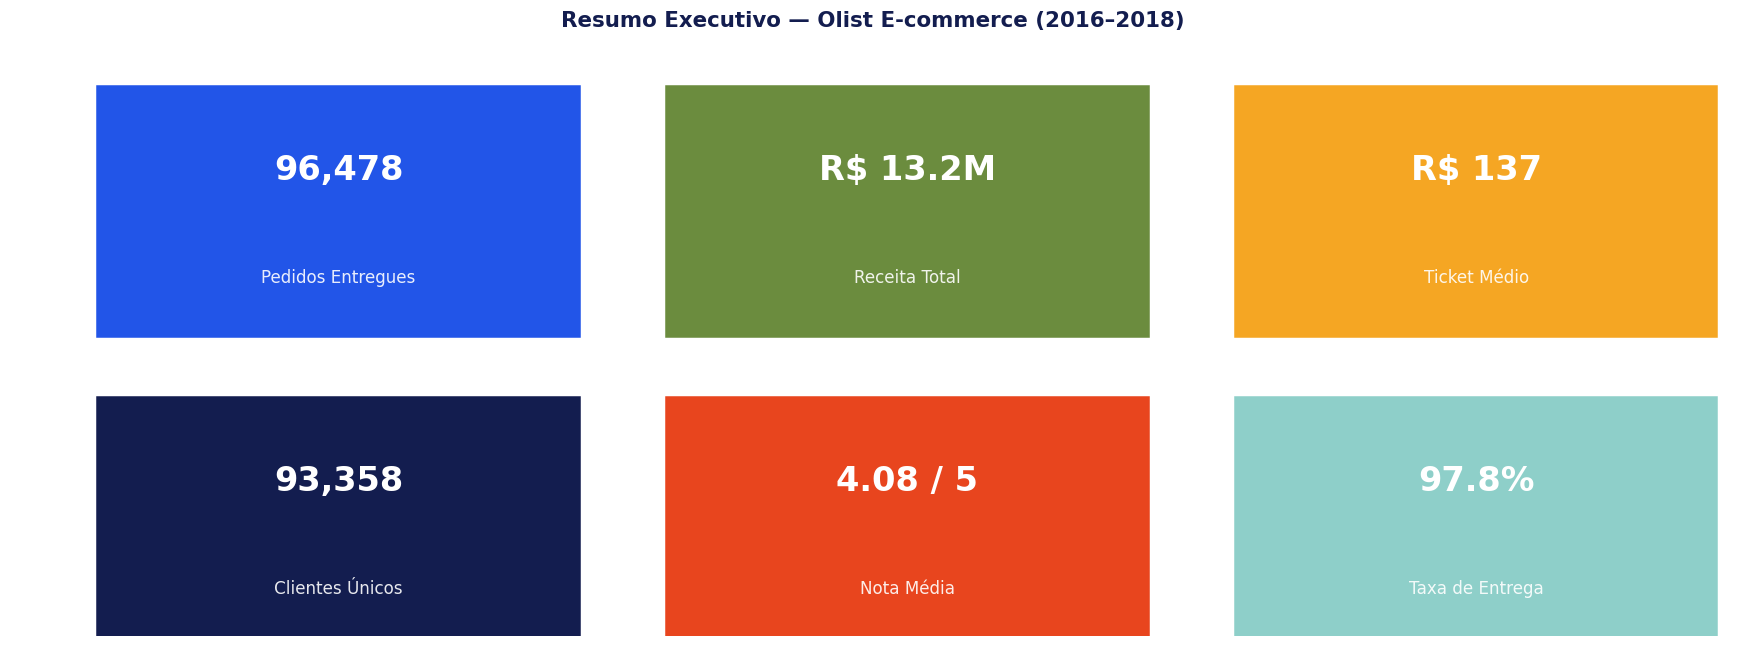

In [4]:
# @title
entregues = base[base['order_status'] == 'delivered']

total_pedidos   = entregues['order_id'].nunique()
receita_total   = entregues.drop_duplicates(subset=['order_id','order_item_id'])['price'].sum()
clientes_unicos = entregues['customer_unique_id'].nunique()
ticket_medio    = receita_total / total_pedidos
nota_media      = entregues['review_score'].mean()
taxa_entrega    = (base['order_status'] == 'delivered').mean() * 100

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

kpis = [
    ('Pedidos Entregues', f'{total_pedidos:,}',           AZUL),
    ('Receita Total',     f'R$ {receita_total/1e6:.1f}M', VERDE),
    ('Ticket Médio',      f'R$ {ticket_medio:.0f}',       LARANJA),
    ('Clientes Únicos',   f'{clientes_unicos:,}',          AZUL_DARK),
    ('Nota Média',        f'{nota_media:.2f} / 5',        VERMELHO),
    ('Taxa de Entrega',   f'{taxa_entrega:.1f}%',          MENTA[0:7]),
]

cols = 3
for i, (titulo, valor, cor) in enumerate(kpis):
    col = i % cols
    row = i // cols
    x = 0.05 + col * 0.33
    y = 0.50 - row * 0.52
    rect = plt.Rectangle((x, y), 0.28, 0.42, transform=ax.transAxes, color=cor, zorder=1)
    ax.add_patch(rect)
    ax.text(x+0.14, y+0.28, valor, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color='white', zorder=2)
    ax.text(x+0.14, y+0.10, titulo, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='white', alpha=0.9, zorder=2)

ax.text(0.5, 1.02, 'Resumo Executivo — Olist E-commerce (2016–2018)',
        transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold', color=AZUL_DARK)
plt.tight_layout()
plt.show()

---
## 3. Crescimento e Receita

### 3.1 Evolução Ano a Ano

A Olist saiu de uma operação embrionária em 2016 — com apenas 312 pedidos — para um negócio de escala nacional. O salto de 2016 para 2017 representa a fase de **lançamento e tração**, enquanto 2017→2018 mostra um crescimento maduro e sustentável de **+20%**.

| Ano | Pedidos | Receita Produto | Receita Frete | Receita Total | Cresc. Pedidos | Cresc. Receita |
|---|---|---|---|---|---|---|
| 2016 | 312 | R\$ 49.786 | R\$ 7.397 | R\$ 57.183 | — | — |
| 2017 | 44.579 | R\$ 6.155.807 | R\$ 986.865 | R\$ 7.142.672 | +14.188% | +12.264% |
| 2018 | 53.775 | R\$ 7.386.051 | R\$ 1.257.647 | R\$ 8.643.698 | **+20,6%** | **+20,0%** |


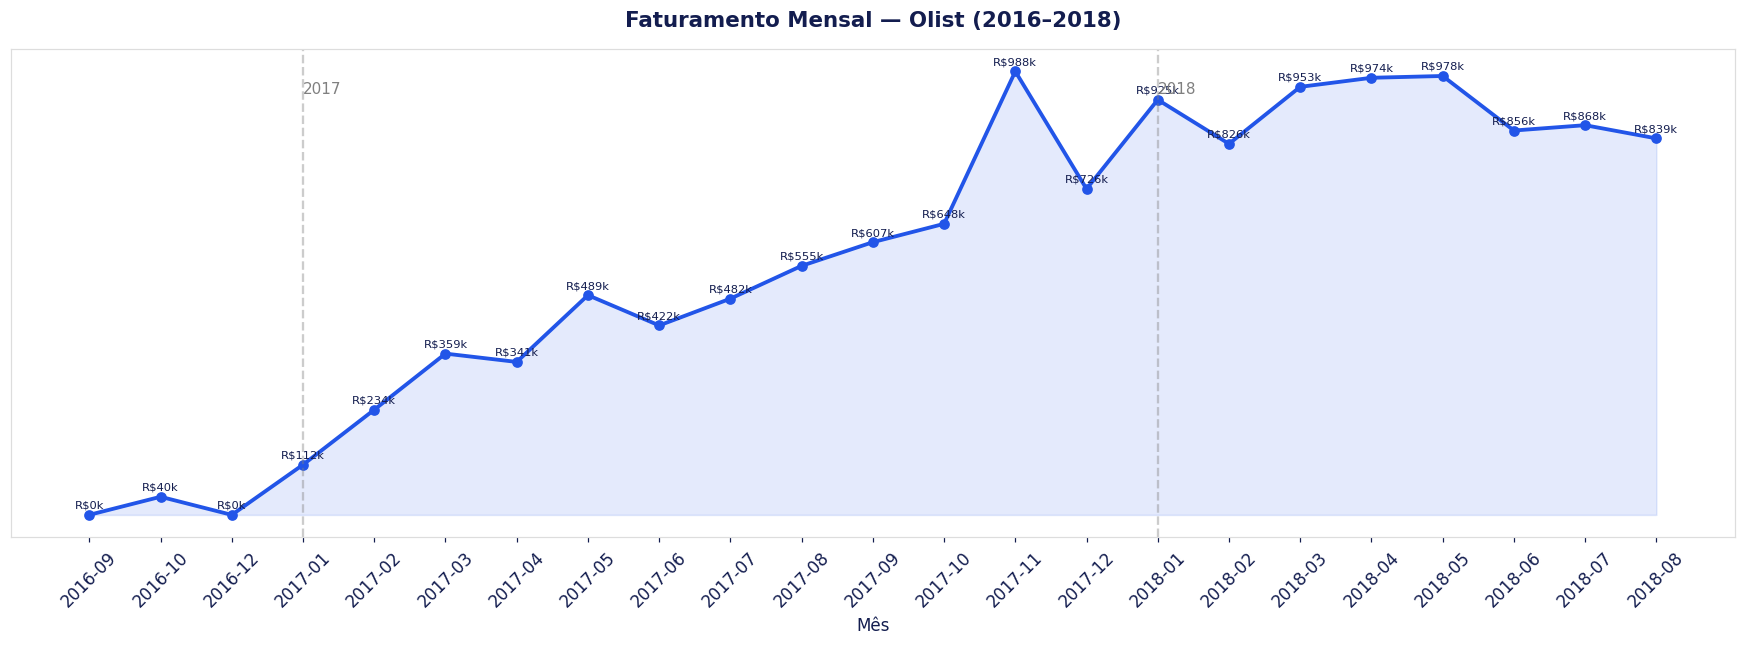

In [5]:
# @title
# Faturamento mensal
entregues_items = entregues.drop_duplicates(subset=['order_id', 'order_item_id']).copy()
entregues_items['ano_mes'] = entregues_items['order_purchase_timestamp'].dt.to_period('M')

mensal = (
    entregues_items.groupby('ano_mes')['price']
    .sum().reset_index().sort_values('ano_mes')
)
mensal['ano_mes_str'] = mensal['ano_mes'].astype(str)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(mensal['ano_mes_str'], mensal['price']/1000,
        color=AZUL, linewidth=2.5, marker='o', markersize=6)
ax.fill_between(mensal['ano_mes_str'], mensal['price']/1000, alpha=0.12, color=AZUL)

for _, row in mensal.iterrows():
    ax.text(row['ano_mes_str'], row['price']/1000 + 15,
            f"R${row['price']/1000:.0f}k", ha='center', fontsize=7.5, color=AZUL_DARK)

for mes in mensal['ano_mes_str']:
    if mes.endswith('-01'):
        ax.axvline(x=mes, color='gray', linestyle='--', alpha=0.4)
        ax.text(mes, mensal['price'].max()/1000*0.95, mes[:4],
                color='gray', fontsize=10, ha='left')

ax.set_title('Faturamento Mensal — Olist (2016–2018)',
             fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Mês', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_visible(False)  # oculta eixo Y (linha + rótulos + ticks)
for spine in ax.spines.values():
    spine.set_edgecolor('#ddd')
plt.tight_layout()
plt.show()

### 3.2 Sazonalidade

Analisando os pedidos por mês (consolidado de todos os anos), observa-se um **padrão de sazonalidade bem definido**:

- **Agosto é o mês de maior volume** (10.745 pedidos), provavelmente oriundo do dia dos pais, seguido de julho (10.242) e maio (10.513) - dia das mães.
- **Setembro e outubro apresentam quedas abruptas**, possivelmente devido ao comportamento de espera pelo Black Friday
- **Novembro recupera** (7.451) — efeito Black Friday — mas não atinge os picos do meio do ano
- O primeiro semestre mantém volumes altos e crescentes, de janeiro a agosto



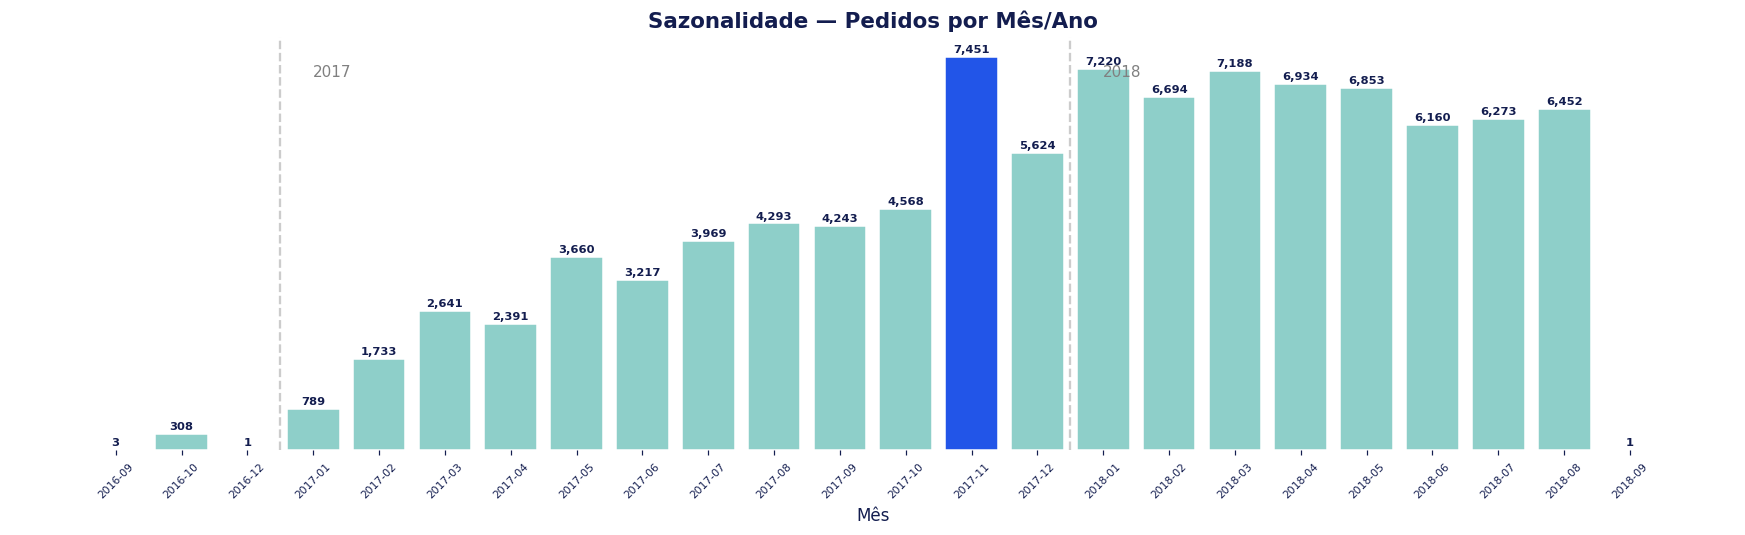

In [6]:
# @title
base['ano_mes'] = base['order_purchase_timestamp'].dt.to_period('M')

sazon = (
    base.drop_duplicates(subset=['order_id', 'order_item_id'])
    .groupby('ano_mes')
    .agg(pedidos=('order_id', 'nunique'))
    .reset_index().sort_values('ano_mes')
)
sazon['ano_mes_str'] = sazon['ano_mes'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

cores = [AZUL if p == sazon['pedidos'].max() else MENTA for p in sazon['pedidos']]
ax.bar(sazon['ano_mes_str'], sazon['pedidos'], color=cores, edgecolor='white')

for i, v in enumerate(sazon['pedidos']):
    ax.text(i, v + 50, f'{v:,}', ha='center', va='bottom',
            fontsize=7.5, color=AZUL_DARK, fontweight='bold')

# Linha divisória entre anos
for mes in sazon['ano_mes_str']:
    if mes.endswith('-01'):
        idx = sazon['ano_mes_str'].tolist().index(mes)
        ax.axvline(x=idx - 0.5, color='gray', linestyle='--', alpha=0.4)
        ax.text(idx, sazon['pedidos'].max() * 0.95, mes[:4],
                color='gray', fontsize=10, ha='left')

ax.yaxis.set_visible(False)
ax.set_title('Sazonalidade — Pedidos por Mês/Ano',
             fontsize=14, fontweight='bold', color=AZUL_DARK)
ax.set_xlabel('Mês', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.tick_params(axis='x', rotation=45, labelsize=7)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
# @title
# Produtos mais vendidos em Janeiro (todos os anos)
janeiro = (
    base[base['mes'] == 1]
    .drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('product_category_name_english')
    .agg(qtd=('order_item_id','count'), receita=('price','sum'))
    .reset_index()
    .sort_values('qtd', ascending=False)
    .head(15)
)

pd.set_option('display.max_rows', None)
print('=== TOP 15 CATEGORIAS — JANEIRO ===')
display(janeiro)

# Produtos mais vendidos em Mar/Abr/Mai 2018
trimestre = (
    base[base['ano_mes'].astype(str).isin(['2018-03','2018-04','2018-05'])]
    .drop_duplicates(subset=['order_id','order_item_id'])
    .groupby(['ano_mes', 'product_category_name_english'])
    .agg(qtd=('order_item_id','count'), receita=('price','sum'))
    .reset_index()
    .sort_values(['ano_mes','qtd'], ascending=[True, False])
)

print('\n=== TOP CATEGORIAS — MAR/ABR/MAI 2018 ===')
display(trimestre.groupby('ano_mes').head(10))
pd.reset_option('display.max_rows')

=== TOP 15 CATEGORIAS — JANEIRO ===


,product_category_name_english,qtd,receita
6,bed_bath_table,896,80337.95
36,furniture_decor,794,68959.49
13,computers_accessories,738,87181.59
62,sports_leisure,734,101291.95
40,health_beauty,713,85031.81
63,stationery,411,42585.90
65,telephony,398,17825.82
46,housewares,387,40905.89
67,watches_gifts,381,83707.76
24,electronics,362,16613.68



=== TOP CATEGORIAS — MAR/ABR/MAI 2018 ===


,ano_mes,product_category_name_english,qtd,receita
6,2018-03,bed_bath_table,798,69256.39
60,2018-03,sports_leisure,761,85292.17
12,2018-03,computers_accessories,758,85673.53
39,2018-03,health_beauty,673,90034.41
35,2018-03,furniture_decor,595,52244.04
65,2018-03,watches_gifts,430,97861.08
45,2018-03,housewares,407,37514.44
4,2018-03,auto,344,44753.24
63,2018-03,telephony,344,25804.89
38,2018-03,garden_tools,262,27612.25


---
## 4. Portfólio de Produtos

### 4.1 Top 10 Categorias por Volume

**Cama, Mesa e Banho** lidera com folga em volume (11.115 itens), mas não é a categoria de maior receita. **Beleza e Saúde** (R\$ 1,26M) e **Saúde e Beleza** (R\$ 1,26M) superam em receita por ter ticket médio mais alto.

Destaque para **Relógios e Presentes** — apesar de estar em 7º lugar em volume (5.991 itens), gera R\$ 1,2M de receita com ticket médio de R\$ 201, demonstrando alto valor por transação.

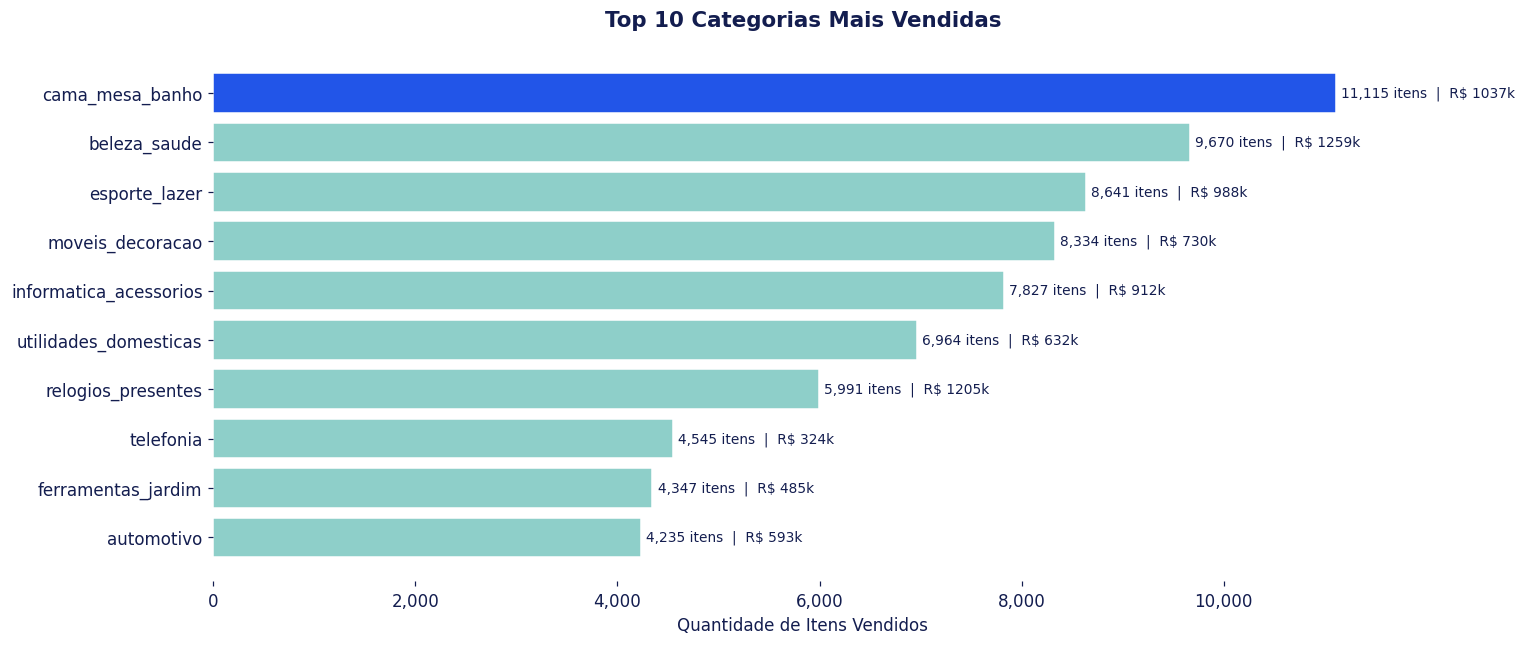

In [8]:
# @title
top10 = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('product_category_name')
    .agg(qtd_vendida=('order_item_id','count'), receita=('price','sum'))
    .reset_index()
    .sort_values('qtd_vendida', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

top10_ord = top10.sort_values('qtd_vendida', ascending=True)
cores = [AZUL if i == 9 else MENTA for i in range(10)]

bars = ax.barh(top10_ord['product_category_name'], top10_ord['qtd_vendida'],
               color=cores, edgecolor='white')

for bar, (_, row) in zip(bars, top10_ord.iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{row['qtd_vendida']:,} itens  |  R$ {row['receita']/1e3:.0f}k",
            va='center', fontsize=9, color=AZUL_DARK)

ax.set_title('Top 10 Categorias Mais Vendidas', fontsize=14,
             fontweight='bold', color=AZUL_DARK, pad=15)
ax.set_xlabel('Quantidade de Itens Vendidos', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

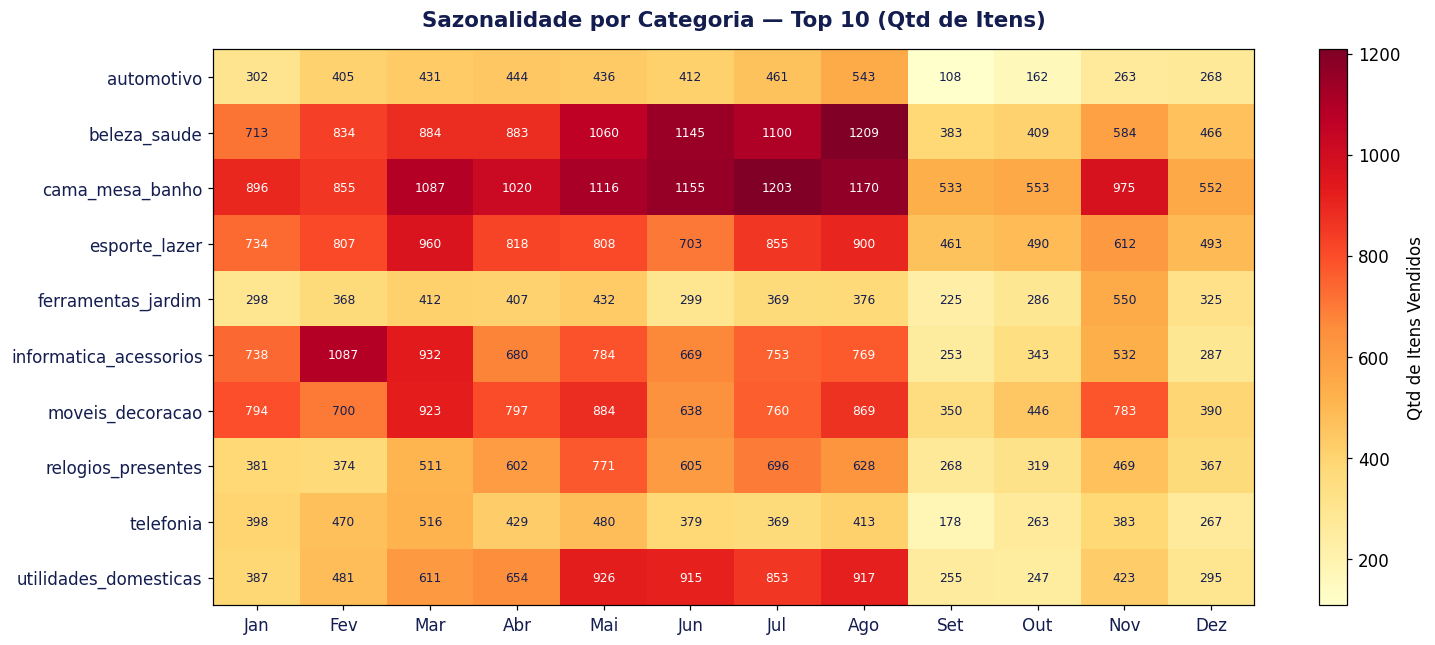

In [9]:
# @title
# Sazonalidade por categoria — média de pedidos por mês
sazon_cat = (
    base.drop_duplicates(subset=['order_id','order_item_id'])
    .groupby(['product_category_name', 'mes'])
    .agg(qtd=('order_item_id','count'))
    .reset_index()
)

# Top 10 categorias por volume total para não poluir o gráfico
top_cats = (
    sazon_cat.groupby('product_category_name')['qtd']
    .sum().sort_values(ascending=False).head(10).index.tolist()
)

sazon_top = sazon_cat[sazon_cat['product_category_name'].isin(top_cats)]

# Heatmap de sazonalidade
pivot = sazon_top.pivot(index='product_category_name', columns='mes', values='qtd').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun',
                    'Jul','Ago','Set','Out','Nov','Dez'], color=AZUL_DARK)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, color=AZUL_DARK)

# Valor dentro de cada célula
for i in range(len(pivot.index)):
    for j in range(12):
        ax.text(j, i, f'{int(pivot.values[i,j])}',
                ha='center', va='center', fontsize=8,
                color='white' if pivot.values[i,j] > pivot.values.max()*0.6 else AZUL_DARK)

plt.colorbar(im, ax=ax, label='Qtd de Itens Vendidos')
ax.set_title('Sazonalidade por Categoria — Top 10 (Qtd de Itens)',
             fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
plt.tight_layout()
plt.show()

### 4.2 Ticket Médio por Categoria


| Posição | Categoria | Ticket Médio |
|---|---|---|
| 1º | Computadores | R\$ 1.098 |
| 2º | Eletrodomésticos Portáteis | R\$ 624 |
| 3º | Eletrodomésticos 2 | R\$ 476 |
| 9º | Relógios/Presentes | R\$ 201 |
| 45º | Cama, Mesa e Banho | R\$ 93 |
| 71º | Casa Conforto 2 | R\$ 25 |

---
## 5. Base de Clientes

### 5.1 Taxa de Recompra

Um dos dados mais relevantes — e desafiadores — desta análise é a **taxa de recompra de apenas 3,1%**. Isso significa que **96,9% dos clientes compraram apenas uma vez** no período analisado.

| Nº de Pedidos | Clientes | % |
|---|---|---|
| 1 pedido | 92.507 | 96,9% |
| 2 pedidos | 2.673 | 2,8% |
| 3+ pedidos | 240 | 0,3% |



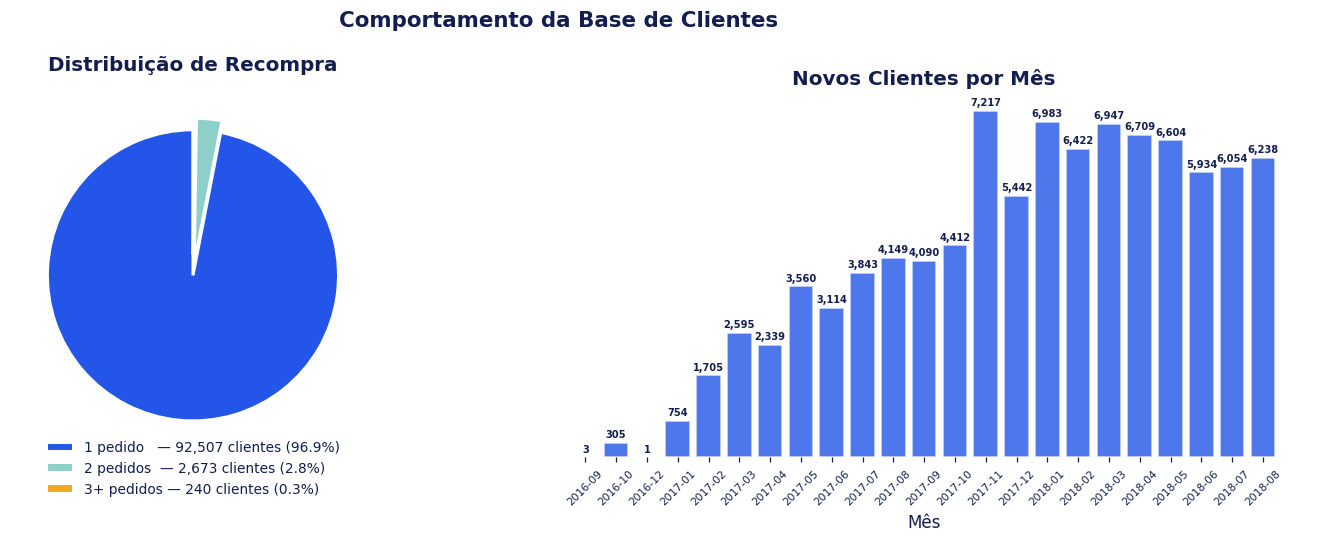

Total de clientes únicos: 95,420
Taxa de recompra        : 3.1%


In [10]:
# @title
recompra = (
    base.drop_duplicates(subset=['order_id'])
    .groupby('customer_unique_id')['order_id']
    .count().reset_index()
    .rename(columns={'order_id': 'qtd_pedidos'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# Gráfico 1: pizza de recompra
ax1 = axes[0]
ax1.set_facecolor('white')

sizes = [
    (recompra['qtd_pedidos']==1).sum(),
    (recompra['qtd_pedidos']==2).sum(),
    (recompra['qtd_pedidos']>2).sum()
]
total_cli   = sum(sizes)
cores_pizza = [AZUL, MENTA, LARANJA]
explode     = (0, 0.08, 0.14)

wedges, _ = ax1.pie(
    sizes, colors=cores_pizza, explode=explode,
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

leg_labels = [
    f'1 pedido   — {sizes[0]:,} clientes ({sizes[0]/total_cli*100:.1f}%)',
    f'2 pedidos  — {sizes[1]:,} clientes ({sizes[1]/total_cli*100:.1f}%)',
    f'3+ pedidos — {sizes[2]:,} clientes ({sizes[2]/total_cli*100:.1f}%)',
]
ax1.legend(wedges, leg_labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.14), fontsize=9,
           frameon=False, labelcolor=AZUL_DARK)
ax1.set_title('Distribuição de Recompra', fontsize=13, fontweight='bold', color=AZUL_DARK, pad=15)

# Gráfico 2: novos clientes por mês
ax2 = axes[1]
ax2.set_facecolor('white')

base['ano_mes'] = base['order_purchase_timestamp'].dt.to_period('M')
primeiro_pedido = (
    base.sort_values('order_purchase_timestamp')
    .drop_duplicates(subset='customer_unique_id', keep='first')
    .groupby('ano_mes')['customer_unique_id']
    .count().reset_index().sort_values('ano_mes')
)
primeiro_pedido['Mes'] = primeiro_pedido['ano_mes'].astype(str)

bars = ax2.bar(primeiro_pedido['Mes'], primeiro_pedido['customer_unique_id'],
               color=AZUL, alpha=0.8, edgecolor='white')

# Valor acima de cada barra
for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(primeiro_pedido['customer_unique_id']) * 0.01,
        f'{int(height):,}',
        ha='center', va='bottom',
        fontsize=6.5, color=AZUL_DARK, fontweight='bold'
    )

ax2.yaxis.set_visible(False)  # oculta eixo Y (linha + rótulos + ticks)

ax2.set_title('Novos Clientes por Mês', fontsize=13, fontweight='bold', color=AZUL_DARK)
ax2.set_xlabel('Mês', color=AZUL_DARK)
ax2.tick_params(axis='x', rotation=45, labelsize=7)
ax2.tick_params(colors=AZUL_DARK)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.suptitle('Comportamento da Base de Clientes', fontsize=14,
             fontweight='bold', color=AZUL_DARK)
plt.tight_layout()
plt.show()

print(f'Total de clientes únicos: {recompra["qtd_pedidos"].count():,}')
print(f'Taxa de recompra        : {(recompra["qtd_pedidos"]>1).mean()*100:.1f}%')

### 5.2 Concentração Geográfica

A base de clientes é **altamente concentrada no eixo SP-RJ-MG**, que juntos representam **66,5% dos clientes únicos**.

| Estado | Clientes | % |
|---|---|---|
| SP | 39.972 | 41,9% |
| RJ | 12.300 | 12,9% |
| MG | 11.175 | 11,7% |
| RS | 5.247 | 5,5% |
| PR | 4.838 | 5,1% |



---
## 6. Logística e Entrega

### 6.1 Performance Logística por Estado

O tempo médio de entrega varia **de 8,3 dias (SP) a 29 dias (RR)**, evidenciando uma disparidade regional significativa. Estados do Norte e Nordeste sofrem com tempos de entrega muito superiores à média nacional, o que impacta diretamente na satisfação do cliente.

**Estados com pior performance de entrega:**
- RR: 29,0 dias | AP: 26,7 dias | AM: 26,0 dias | AL: 24,0 dias | PA: 23,3 dias

**Estados com melhor performance:**
- SP: 8,3 dias | PR: 11,5 dias | MG: 11,5 dias | DF: 12,5 dias

### 6.2 Taxa de Atraso

A **taxa de atraso geral é de 8%**, mas com variação expressiva por estado. AL lidera com 23,9% de atraso — quase 1 em cada 4 pedidos chega depois do prazo prometido.

| Estado | Taxa de Atraso | Estado | Taxa de Atraso |
|---|---|---|---|
| AL | 23,9% | SP | 5,9% |
| MA | 19,7% | MG | 5,6% |
| PI | 16,0% | PR | 5,0% |
| CE | 15,3% | RO | 2,9% |

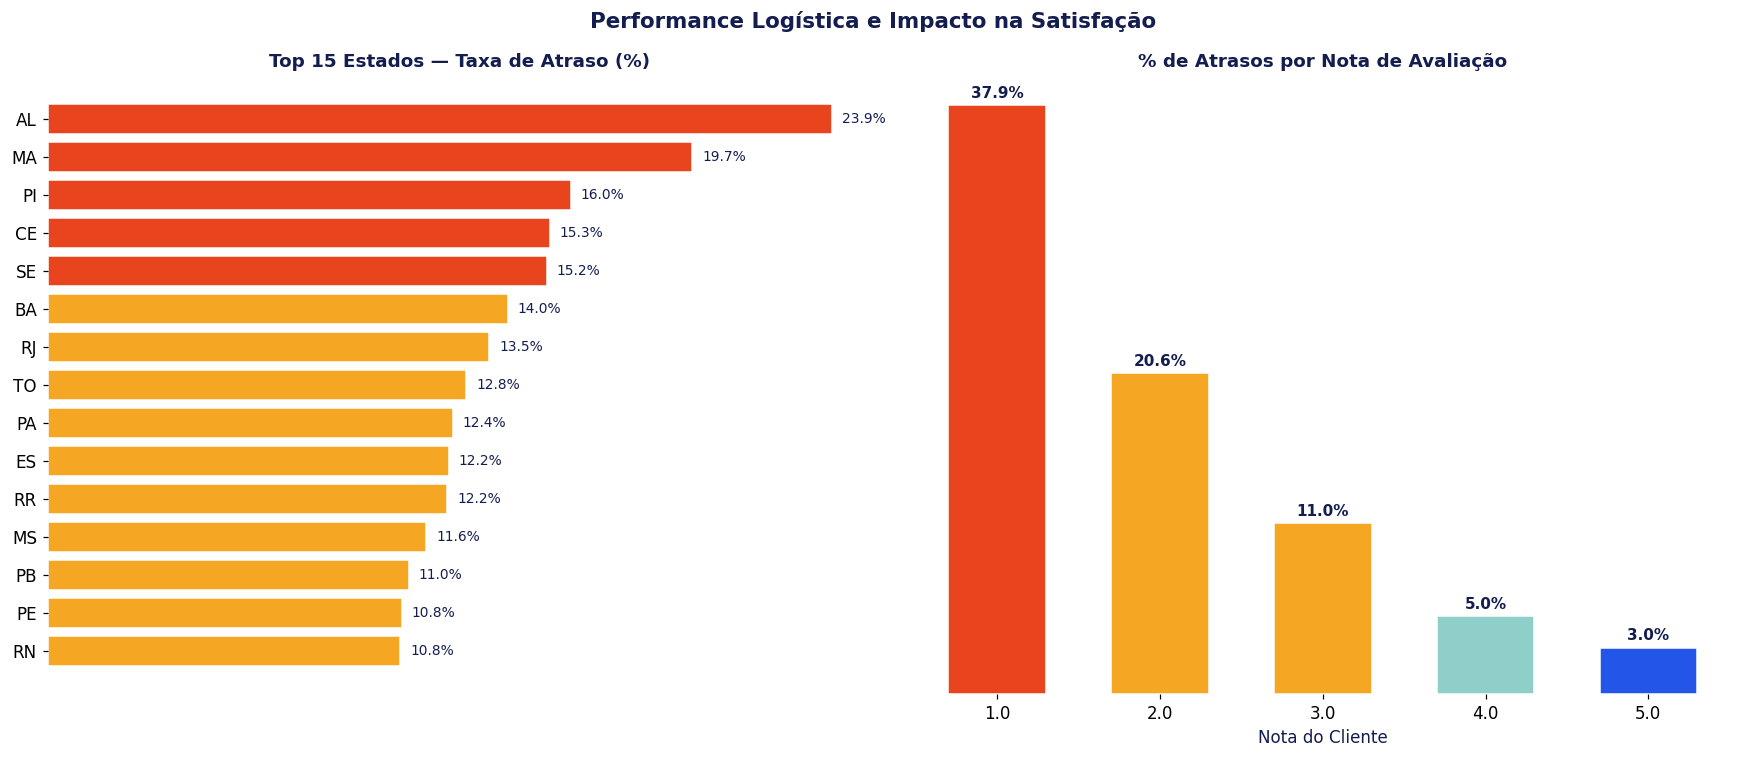

In [11]:
# @title
df_log = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .assign(
        dias_entrega=lambda x: (x['order_delivered_customer_date'] - x['order_purchase_timestamp']).dt.days,
        atrasado=lambda x: x['order_delivered_customer_date'] > x['order_estimated_delivery_date']
    )
)

estado_log = (
    df_log.groupby('customer_state')
    .agg(
        dias_medio  = ('dias_entrega', 'mean'),
        pct_atraso  = ('atrasado',     'mean')
    )
    .reset_index()
    .sort_values('pct_atraso', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

ax1 = axes[0]
ax1.set_facecolor('white')
ord1 = estado_log.sort_values('pct_atraso', ascending=True)
cores = [VERMELHO if v > 0.15 else LARANJA if v > 0.10 else MENTA for v in ord1['pct_atraso']]
ax1.barh(ord1['customer_state'], ord1['pct_atraso']*100, color=cores, edgecolor='white')
for i, (_, row) in enumerate(ord1.iterrows()):
    ax1.text(row['pct_atraso']*100 + 0.3, i, f"{row['pct_atraso']*100:.1f}%",
             va='center', fontsize=9, color=AZUL_DARK)
ax1.set_title('Top 15 Estados — Taxa de Atraso (%)', fontsize=12,
              fontweight='bold', color=AZUL_DARK)
ax1.set_xlabel('Taxa de Atraso', color=AZUL_DARK)
ax1.xaxis.set_visible(False)  # oculta eixo X (horizontal, pois é barh)
for spine in ax1.spines.values(): spine.set_visible(False)

ax2 = axes[1]
ax2.set_facecolor('white')
df_nota = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .assign(atrasado=lambda x: x['order_delivered_customer_date'] > x['order_estimated_delivery_date'])
    .groupby('review_score')
    .agg(pct_atraso=('atrasado', 'mean'))
    .reset_index()
)
cores_nota = [VERMELHO, LARANJA, LARANJA, MENTA, AZUL]

bars = ax2.bar(df_nota['review_score'].astype(str), df_nota['pct_atraso']*100,
               color=cores_nota, edgecolor='white', width=0.6)
for bar, (_, row) in zip(bars, df_nota.iterrows()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{row['pct_atraso']*100:.1f}%", ha='center', fontsize=10,
             fontweight='bold', color=AZUL_DARK)
ax2.set_title('% de Atrasos por Nota de Avaliação', fontsize=12,
              fontweight='bold', color=AZUL_DARK)
ax2.set_xlabel('Nota do Cliente', color=AZUL_DARK)
ax2.yaxis.set_visible(False)  # oculta eixo Y (linha + rótulos + ticks)
for spine in ax2.spines.values(): spine.set_visible(False)

plt.suptitle('Performance Logística e Impacto na Satisfação',
             fontsize=14, fontweight='bold', color=AZUL_DARK)
plt.tight_layout()
plt.show()

### 6.3 Atraso como Preditor de Insatisfação

A correlação entre atraso e nota baixa é **estatisticamente clara e operacionalmente relevante**:

| Nota | % Adiantado | % Em dia | % Atrasado |
|---|---|---|---|
| ⭐ 1 | 62,1% | 1,2% | **36,7%** |
| ⭐⭐ 2 | 79,4% | 1,7% | **18,9%** |
| ⭐⭐⭐ 3 | 89,0% | 2,2% | 8,8% |
| ⭐⭐⭐⭐ 4 | 95,0% | 1,6% | 3,4% |
| ⭐⭐⭐⭐⭐ 5 | 97,0% | 1,1% | 1,9% |



---
## 7. Satisfação do Cliente

### 7.1 Nota Média Geral e por Categoria

A nota média geral da plataforma é **4,08 / 5,0** — um resultado positivo, mas com variação importante entre categorias.

**Categorias com melhor avaliação** (nota > 4,4):
- CDs/DVDs (4,67) | La Cuisine (4,55) | Roupas Infantis (4,50) | Livros (4,47)

**Categorias com pior avaliação** (nota < 3,9):
- Segurança e Serviços (2,50) | Móveis de Escritório (3,62) | Moda Feminina (3,69)
- Fraldas e Higiene (3,74) | Colchões e Estofados (3,82)

### 7.2 Top Categorias com Reclamações (Nota 1)

As categorias mais volumosas também concentram o maior número absoluto de reclamações:

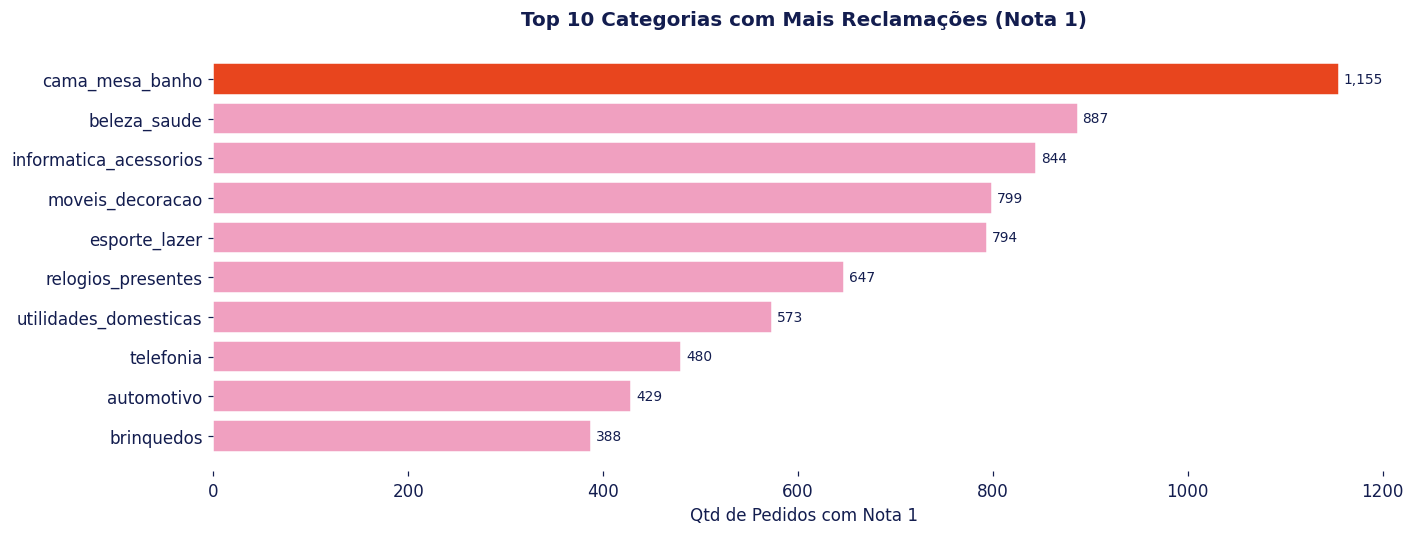

In [12]:
# @title
reclamacoes = (
    base[base['review_score'] == 1]
    .drop_duplicates(subset='order_id')
    .groupby('product_category_name')
    .agg(qtd=('order_id','count'))
    .reset_index()
    .sort_values('qtd', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

rec_ord = reclamacoes.sort_values('qtd', ascending=True)
cores = [VERMELHO if i == 9 else ROSA for i in range(10)]
bars = ax.barh(rec_ord['product_category_name'], rec_ord['qtd'],
               color=cores, edgecolor='white')
for bar, (_, row) in zip(bars, rec_ord.iterrows()):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f"{row['qtd']:,}", va='center', fontsize=9, color=AZUL_DARK)

ax.set_title('Top 10 Categorias com Mais Reclamações (Nota 1)',
             fontsize=13, fontweight='bold', color=AZUL_DARK, pad=12)
ax.set_xlabel('Qtd de Pedidos com Nota 1', color=AZUL_DARK)
ax.tick_params(colors=AZUL_DARK)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.show()

### 7.3 Análise Qualitativa — O que os Clientes Reclamam?

A análise dos comentários da categoria **Cama, Mesa e Banho** — líder em reclamações absolutas (1.155 pedidos com nota 1) — revela **4 eixos principais de insatisfação**:

**1. Entrega Incompleta** (~35% dos comentários)
> *"Comprei 2 e só veio 1"*, *"Recebi somente 1 produto apesar de ter pedido e pago 2"*

**2. Produto Diferente da Foto** (~25% dos comentários)
> *"Material totalmente diferente do anunciado"*, *"Cor completamente diferente da propaganda"*

**3. Não Entregue / Atraso Extremo** (~25% dos comentários)
> *"Prazo esgotado, produto não entregue"*, *"Mais de um mês esperando"*

**4. Qualidade Inferior** (~15% dos comentários)
> *"Tecido muito fino"*, *"Produto de péssima qualidade, nada a ver com a foto"*



---
## 8. Meios de Pagamento

### 8.1 Distribuição por Método

O **cartão de crédito domina com 75,9%** dos pedidos, seguido pelo boleto bancário (19,9%). O parcelamento é amplamente utilizado, especialmente em categorias de ticket alto.

| Método | Pedidos | Receita | Ticket Médio | % |
|---|---|---|---|---|
| Cartão de Crédito | 74.883 | R\$ 12,3M | R\$ 164 | 75,9% |
| Boleto | 19.614 | R\$ 2,8M | R\$ 145 | 19,9% |
| Voucher | 2.648 | R\$ 213k | R\$ 81 | 2,7% |
| Débito | 1.520 | R\$ 215k | R\$ 141 | 1,5% |

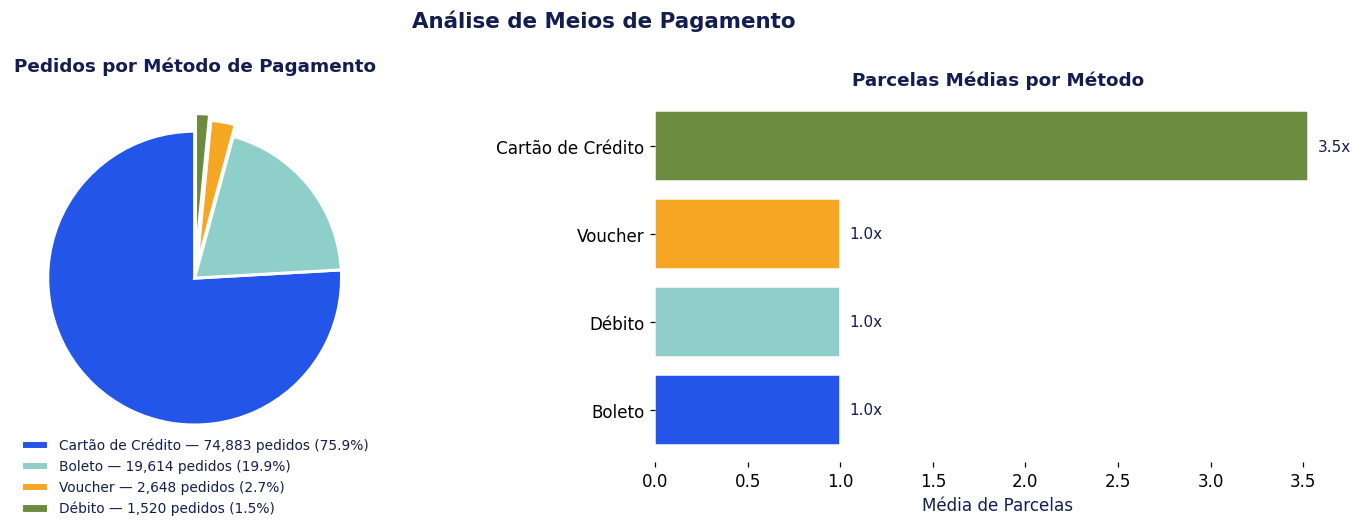

In [13]:
# @title
pag = (
    base.drop_duplicates(subset='order_id')
    .groupby('payment_type')
    .agg(qtd=('order_id','count'), receita=('payment_value','sum'))
    .reset_index()
    .sort_values('qtd', ascending=False)
)

nomes = {'credit_card':'Cartão de Crédito','boleto':'Boleto',
         'voucher':'Voucher','debit_card':'Débito'}
pag['metodo'] = pag['payment_type'].map(nomes).fillna(pag['payment_type'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ax1 = axes[0]
ax1.set_facecolor('white')
cores_pag   = [AZUL, MENTA, LARANJA, VERDE]
explode_pag = [0, 0, 0.08, 0.12]
total_pag   = pag['qtd'].sum()

wedges, _ = ax1.pie(
    pag['qtd'], colors=cores_pag,
    explode=explode_pag, startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

leg_pag = [
    f"{row['metodo']} — {row['qtd']:,} pedidos ({row['qtd']/total_pag*100:.1f}%)"
    for _, row in pag.iterrows()
]
ax1.legend(wedges, leg_pag, loc='lower center',
           bbox_to_anchor=(0.5, -0.18), fontsize=9,
           frameon=False, labelcolor=AZUL_DARK)
ax1.set_title('Pedidos por Método de Pagamento',
              fontsize=12, fontweight='bold', color=AZUL_DARK, pad=15)

ax2 = axes[1]
ax2.set_facecolor('white')
parc = (
    base.drop_duplicates(subset='order_id')
    .groupby('payment_type')['payment_installments']
    .mean().reset_index()
)
parc['metodo'] = parc['payment_type'].map(nomes).fillna(parc['payment_type'])
parc = parc.sort_values('payment_installments', ascending=True)
ax2.barh(parc['metodo'], parc['payment_installments'],
         color=[AZUL, MENTA, LARANJA, VERDE], edgecolor='white')
for i, (_, row) in enumerate(parc.iterrows()):
    ax2.text(row['payment_installments']+0.05, i,
             f"{row['payment_installments']:.1f}x",
             va='center', fontsize=10, color=AZUL_DARK)
ax2.set_title('Parcelas Médias por Método',
              fontsize=12, fontweight='bold', color=AZUL_DARK)
ax2.set_xlabel('Média de Parcelas', color=AZUL_DARK)
for spine in ax2.spines.values(): spine.set_visible(False)

plt.suptitle('Análise de Meios de Pagamento',
             fontsize=14, fontweight='bold', color=AZUL_DARK)
plt.tight_layout()
plt.show()

### 8.2 Parcelamento por Categoria

O parcelamento médio no crédito é de **3,0x**, mas varia bastante por categoria:
- **Computadores:** 6,2x | **Eletrodomésticos Portáteis:** 5,5x | **Eletrodomésticos:** 4,5x
- **Cama/Mesa/Banho:** 3,6x | **Beleza/Saúde:** 3,0x | **Eletrônicos:** 1,7x


---
## 9. Ecossistema de Vendedores

### 9.1 Concentração de Receita

A plataforma possui **3.095 vendedores ativos**, com uma distribuição de receita relativamente saudável. Os **top 10 vendedores representam apenas ~12% da receita total** — sinal de que não há dependência excessiva de poucos parceiros.

### 9.2 Distribuição Geográfica dos Vendedores

| Estado | Vendedores | % |
|---|---|---|
| SP | 1.849 | 59,7% |
| PR | 349 | 11,3% |
| MG | 244 | 7,9% |
| SC | 190 | 6,1% |
| RJ | 171 | 5,5% |

> SP concentra quase 60% dos vendedores, o que explica parcialmente a melhor performance logística do estado — produtos saem mais perto dos grandes centros consumidores.

---
## 10. Projeções

### Receita
Com base na série histórica de 2017–2018, elaboramos uma projeção para os próximos cinco anos utilizando o método CAGR (Compound Annual Growth Rate). A taxa de crescimento observada entre 2017 e 2018 foi de 20,6% ao ano — excluímos 2016 por representar apenas 4 meses de operação, o que distorceria a taxa base.

Aplicando esse crescimento composto sobre a receita de 2018 de 8,6M de reais, a projeção aponta para uma operação de R$ 22,2M até 2023 um crescimento de aproximadamente 2,6x em cinco anos.


| Ano | Receita Projetada | Crescimento vs.2018 |
|---|---|---|
| 2019 | 10,4M | 20,6% |
| 2020 | 12,6M | 45,8% |
| 2021 | 15,2M | 75,5% |
| 2022 | 18,3M | 112,2% |
| 2023 | 22,1M | 155,8% |

>Limitações do modelo: A projeção por CAGR assume que a taxa de crescimento permanece constante — o que raramente ocorre em mercados dinâmicos. Fatores como saturação de mercado, entrada de concorrentes, crises econômicas ou mudanças regulatórias não estão capturados no modelo. A base histórica de apenas 2 anos também limita a precisão da extrapolação. Os valores devem ser interpretados como referência de tendência, não como previsão precisa.

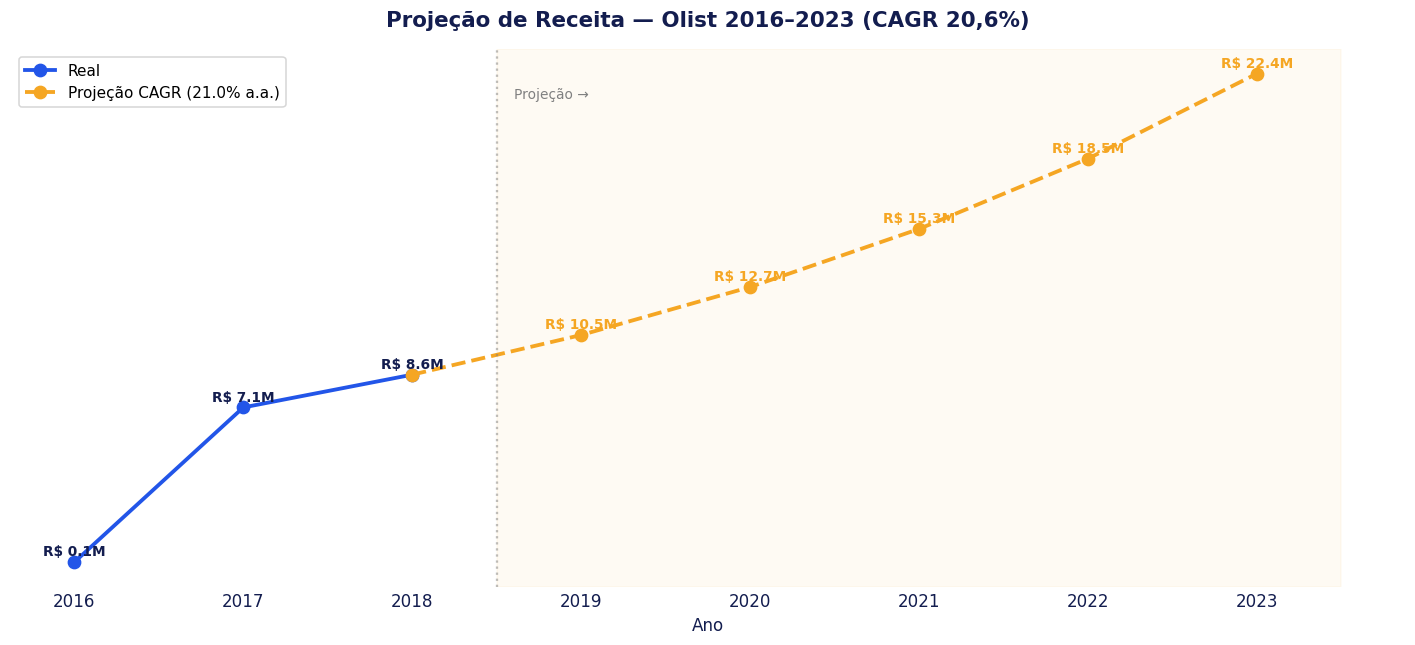

In [14]:
  # @title
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt

  AZUL      = '#2255E8'
  AZUL_DARK = '#131D4F'
  LARANJA   = '#F5A623'
  VERMELHO  = '#E8451E'

  receita_2017 = 7_142_672
  receita_2018 = 8_643_698
  cagr = (receita_2018 / receita_2017) - 1

  anos   = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
  valores = [57_183, receita_2017, receita_2018] + \
            [receita_2018 * (1 + cagr)**i for i in range(1, 6)]

  df_proj = pd.DataFrame({'ano': anos, 'receita': valores})
  df_proj['tipo'] = ['Real']*3 + ['Projeção']*5

  fig, ax = plt.subplots(figsize=(13, 6))
  fig.patch.set_facecolor('white')
  ax.set_facecolor('white')

  # Linha histórica
  reais = df_proj[df_proj['tipo'] == 'Real']
  ax.plot(reais['ano'], reais['receita']/1e6,
          color=AZUL, linewidth=2.5, marker='o', markersize=8, label='Real')

  # Linha projetada (começa no último ponto real)
  proj = df_proj[df_proj['tipo'].isin(['Real', 'Projeção'])].tail(6)
  ax.plot(proj['ano'], proj['receita']/1e6,
          color=LARANJA, linewidth=2.5, marker='o', markersize=8,
          linestyle='--', label=f'Projeção CAGR ({cagr*100:.1f}% a.a.)')

  # Rótulos em cada ponto
  for _, row in df_proj.iterrows():
      ax.text(row['ano'], row['receita']/1e6 + 0.3,
              f"R$ {row['receita']/1e6:.1f}M",
              ha='center', fontsize=9, fontweight='bold',
              color=AZUL_DARK if row['tipo'] == 'Real' else LARANJA)

  # Área sombreada de projeção
  ax.axvspan(2018.5, 2023.5, alpha=0.05, color=LARANJA)
  ax.axvline(x=2018.5, color='gray', linestyle=':', alpha=0.5)
  ax.text(2018.6, df_proj['receita'].max()/1e6 * 0.95,
          'Projeção →', color='gray', fontsize=9)

  ax.set_title('Projeção de Receita — Olist 2016–2023 (CAGR 20,6%)',
              fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
  ax.set_xlabel('Ano', color=AZUL_DARK)

  ax.tick_params(colors=AZUL_DARK)
  ax.legend(fontsize=10)
  for spine in ax.spines.values():
      spine.set_visible(False)

  ax.tick_params(axis='x', length=0)

  ax.yaxis.set_visible(False)

  plt.tight_layout()
  plt.show()

---
***Estudos adicionais

In [15]:
ticket_medio = 89  # R$ médio por pedido
clientes_unicos = 95_420
taxa_atual = 0.031

cenarios = [0.05, 0.08, 0.10, 0.15, 0.20]

print(f"{'Taxa Recompra':>15} {'Clientes Retidos':>18} {'Pedidos Extras':>15} {'Receita Extra':>15}")
print("-" * 68)
for taxa in cenarios:
    clientes_retidos = int(clientes_unicos * taxa)
    pedidos_extras   = clientes_retidos - int(clientes_unicos * taxa_atual)
    receita_extra    = pedidos_extras * ticket_medio
    print(f"{taxa*100:>14.0f}% {clientes_retidos:>18,} {pedidos_extras:>15,}  R$ {receita_extra:>12,.0f}")

  Taxa Recompra   Clientes Retidos  Pedidos Extras   Receita Extra
--------------------------------------------------------------------
             5%              4,771           1,813  R$      161,357
             8%              7,633           4,675  R$      416,075
            10%              9,542           6,584  R$      585,976
            15%             14,313          11,355  R$    1,010,595
            20%             19,084          16,126  R$    1,435,214


In [16]:
from datetime import datetime

data_ref = base['order_purchase_timestamp'].max()

rfm = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('customer_unique_id')
    .agg(
        recencia    = ('order_purchase_timestamp', lambda x: (data_ref - x.max()).days),
        frequencia  = ('order_id',  'nunique'),
        valor_total = ('price',     'sum')
    )
    .reset_index()
)

# Score de 1 a 3 para cada dimensão
rfm['r_score'] = pd.qcut(rfm['recencia'],    q=3, labels=[3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequencia'].rank(method='first'), q=3, labels=[1,2,3]).astype(int)
rfm['m_score'] = pd.qcut(rfm['valor_total'], q=3, labels=[1,2,3]).astype(int)
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Segmentos
def segmentar(row):
    if row['rfm_total'] >= 8:
        return 'Champions'
    elif row['rfm_total'] >= 6:
        return 'Leais'
    elif row['r_score'] >= 2:
        return 'Potenciais'
    else:
        return 'Em risco'

rfm['segmento'] = rfm.apply(segmentar, axis=1)

pd.set_option('display.max_rows', None)
display(rfm.groupby('segmento').agg(
    clientes    = ('customer_unique_id', 'count'),
    valor_medio = ('valor_total',        'mean'),
    recencia_media = ('recencia',        'mean')
).sort_values('valor_medio', ascending=False).round(1))
pd.reset_option('display.max_rows')

,clientes,valor_medio,recencia_media
segmento,,,
Champions,14265,253.1,117.2
Leais,44242,156.1,213.6
Em risco,20836,97.4,422.1
Potenciais,14015,48.2,188.1


In [17]:
ltv = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset=['order_id','order_item_id'])
    .groupby('customer_unique_id')
    .agg(pedidos=('order_id','nunique'), gasto_total=('price','sum'))
    .reset_index()
)

print("LTV (Lifetime Value) médio por perfil de cliente:")
print(f"  Comprou 1x   : R$ {ltv[ltv['pedidos']==1]['gasto_total'].mean():.2f}")
print(f"  Comprou 2x   : R$ {ltv[ltv['pedidos']==2]['gasto_total'].mean():.2f}")
print(f"  Comprou 3x+  : R$ {ltv[ltv['pedidos']>=3]['gasto_total'].mean():.2f}")
print(f"\nMultiplicador de valor (3x+ vs 1x): {ltv[ltv['pedidos']>=3]['gasto_total'].mean() / ltv[ltv['pedidos']==1]['gasto_total'].mean():.1f}x")

LTV (Lifetime Value) médio por perfil de cliente:
  Comprou 1x   : R$ 137.96
  Comprou 2x   : R$ 245.35
  Comprou 3x+  : R$ 426.03

Multiplicador de valor (3x+ vs 1x): 3.1x


In [18]:
# ── Referência temporal ─────────────────────────────────────
data_ref = base['order_purchase_timestamp'].max()

# ── Perfil de cada cliente ──────────────────────────────────
clientes = (
    base[base['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .groupby('customer_unique_id')
    .agg(
        ultimo_pedido = ('order_purchase_timestamp', 'max'),
        qtd_pedidos   = ('order_id',  'nunique'),
        gasto_total   = ('price',     'sum')
    )
    .reset_index()
)
clientes['dias_desde_compra'] = (data_ref - clientes['ultimo_pedido']).dt.days

# ── Métricas base ───────────────────────────────────────────
total_clientes          = len(clientes)
recompradores_atuais    = (clientes['qtd_pedidos'] > 1).sum()
taxa_atual              = recompradores_atuais / total_clientes

# Clientes "quentes": compraram nos últimos 6 meses e nunca recompraram
# São o pool mais provável de responder a uma ação de fidelização
clientes_quentes = clientes[
    (clientes['dias_desde_compra'] <= 180) &
    (clientes['qtd_pedidos'] == 1)
]

# LTV comparativo
ltv_1x  = clientes[clientes['qtd_pedidos'] == 1]['gasto_total'].mean()
ltv_2x  = clientes[clientes['qtd_pedidos'] == 2]['gasto_total'].mean()
ltv_3x  = clientes[clientes['qtd_pedidos'] >= 3]['gasto_total'].mean()

print("=" * 60)
print(f"Total de clientes únicos      : {total_clientes:,}")
print(f"Recompradores atuais          : {recompradores_atuais:,} ({taxa_atual*100:.1f}%)")
print(f"Clientes quentes (pool)       : {len(clientes_quentes):,}")
print("=" * 60)
print(f"\nLTV médio — 1 compra          : R$ {ltv_1x:.2f}")
print(f"LTV médio — 2 compras         : R$ {ltv_2x:.2f}  ({ltv_2x/ltv_1x:.1f}x mais)")
print(f"LTV médio — 3+ compras        : R$ {ltv_3x:.2f}  ({ltv_3x/ltv_1x:.1f}x mais)")

# ── Cenários derivados dos dados ────────────────────────────
print("\n" + "=" * 60)
print(f"{'Conversão':>10} {'Novos Recompr.':>16} {'Nova Taxa':>11} {'Crescimento':>13}")
print("-" * 60)
for pct in [0.05, 0.10, 0.15, 0.20, 0.30]:
    novos       = int(len(clientes_quentes) * pct)
    nova_taxa   = (recompradores_atuais + novos) / total_clientes
    delta_pp    = (nova_taxa - taxa_atual) * 100
    print(f"{pct*100:>9.0f}%  {novos:>15,}  {nova_taxa*100:>9.1f}%  +{delta_pp:>9.1f} pp")

Total de clientes únicos      : 93,358
Recompradores atuais          : 2,801 (3.0%)
Clientes quentes (pool)       : 36,083

LTV médio — 1 compra          : R$ 126.49
LTV médio — 2 compras         : R$ 215.04  (1.7x mais)
LTV médio — 3+ compras        : R$ 344.52  (2.7x mais)

 Conversão   Novos Recompr.   Nova Taxa   Crescimento
------------------------------------------------------------
        5%            1,804        4.9%  +      1.9 pp
       10%            3,608        6.9%  +      3.9 pp
       15%            5,412        8.8%  +      5.8 pp
       20%            7,216       10.7%  +      7.7 pp
       30%           10,824       14.6%  +     11.6 pp


In [19]:
ltv_1x = 126.49
ltv_2x = 215.04
pool   = len(clientes_quentes)

print("=" * 72)
print(f"{'Cenário':>12} {'Conversão':>10} {'Novos Recompr.':>16} "
      f"{'Nova Taxa':>10} {'Receita Incr.':>15}")
print("-" * 72)

cenarios = [
    ('Conservador', 0.05),
    ('Base',        0.10),
    ('Otimista',    0.15),
]

for nome, pct in cenarios:
    novos            = int(pool * pct)
    nova_taxa        = (recompradores_atuais + novos) / total_clientes
    # Receita incremental = novos recompradores x (LTV 2x - LTV 1x)
    receita_incr     = novos * (ltv_2x - ltv_1x)
    print(f"{nome:>12}  {pct*100:>8.0f}%  {novos:>15,}  "
          f"{nova_taxa*100:>8.1f}%   R$ {receita_incr:>10,.0f}")

print("=" * 72)

# Argumento executivo
novos_base    = int(pool * 0.10)
receita_base  = novos_base * (ltv_2x - ltv_1x)
multiplicador = ltv_2x / ltv_1x

print(f"""
ARGUMENTO EXECUTIVO
───────────────────────────────────────────────────────────────
Pool disponível       : {pool:,} clientes quentes (compra ≤ 6 meses atrás)
LTV cliente 1 compra  : R$ {ltv_1x:.2f}
LTV cliente 2 compras : R$ {ltv_2x:.2f}  ({multiplicador:.1f}x mais)
Ganho por conversão   : R$ {ltv_2x - ltv_1x:.2f} por cliente reengajado

Cenário Base (10% conversão)
  → {novos_base:,} clientes reengajados
  → R$ {receita_base:,.0f} de receita incremental
  → Sem custo de aquisição de novo cliente
───────────────────────────────────────────────────────────────
""")

     Cenário  Conversão   Novos Recompr.  Nova Taxa   Receita Incr.
------------------------------------------------------------------------
 Conservador         5%            1,804       4.9%   R$    159,744
        Base        10%            3,608       6.9%   R$    319,488
    Otimista        15%            5,412       8.8%   R$    479,233

ARGUMENTO EXECUTIVO
───────────────────────────────────────────────────────────────
Pool disponível       : 36,083 clientes quentes (compra ≤ 6 meses atrás)
LTV cliente 1 compra  : R$ 126.49
LTV cliente 2 compras : R$ 215.04  (1.7x mais)
Ganho por conversão   : R$ 88.55 por cliente reengajado

Cenário Base (10% conversão)
  → 3,608 clientes reengajados
  → R$ 319,488 de receita incremental
  → Sem custo de aquisição de novo cliente
───────────────────────────────────────────────────────────────



  Ano   Pool Quente   Convertidos     Incr. Ano   Incr. Acum.   Receita Total
------------------------------------------------------------------------------
 2018        36,083         3,608  R$     319k  R$     319k  R$     8.96M
 2019        43,516         4,351  R$     385k  R$     705k  R$    10.81M
 2020        52,480         5,248  R$     465k  R$    1169k  R$    13.04M
 2021        63,291         6,329  R$     560k  R$    1730k  R$    15.72M
 2022        76,329         7,632  R$     676k  R$    2406k  R$    18.96M
 2023        92,053         9,205  R$     815k  R$    3221k  R$    22.87M


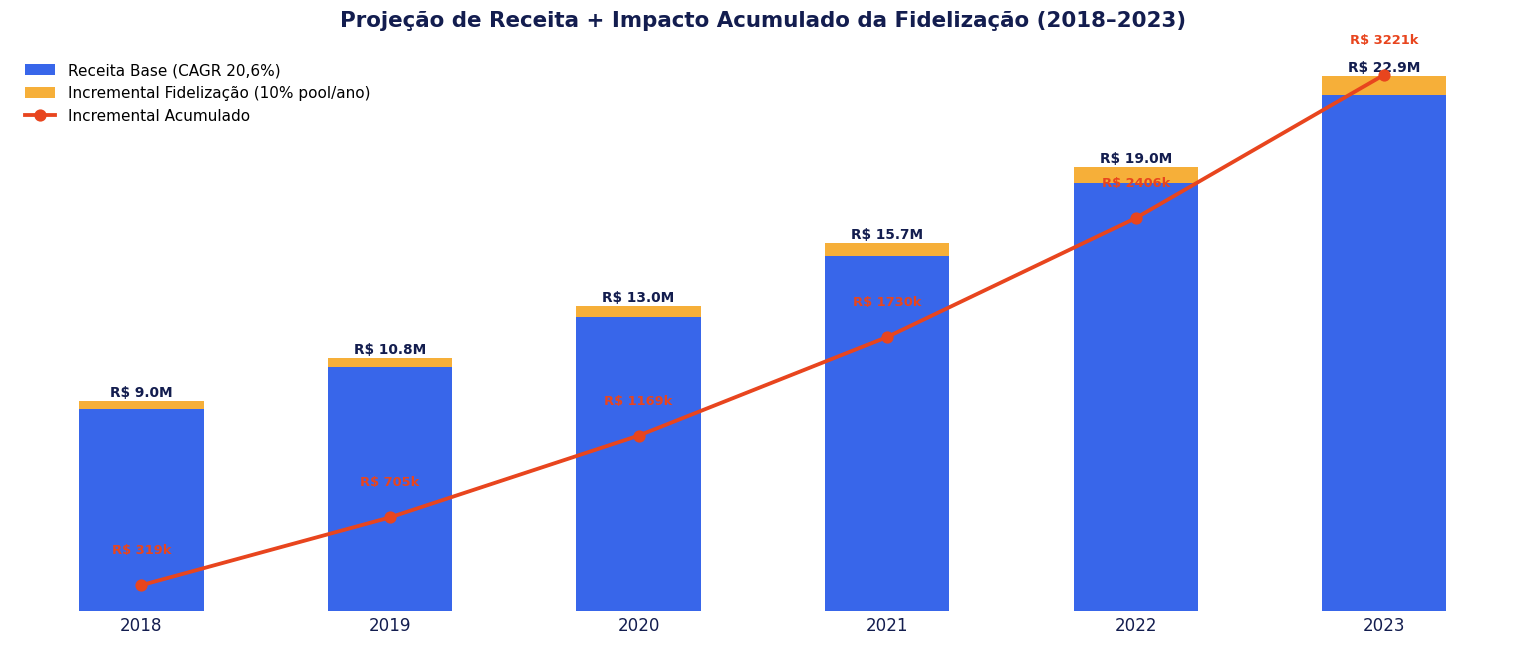

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Parâmetros ──────────────────────────────────────────────
receita_2018  = 8_643_698
cagr          = 0.206
pool_2018     = 36_083
ltv_ganho     = ltv_2x - ltv_1x   # R$ 88,55 por cliente convertido
conversao     = 0.10               # cenário base

anos = [2018, 2019, 2020, 2021, 2022, 2023]

receita_cagr       = [receita_2018 * (1 + cagr)**i for i in range(6)]
pool_ano           = [pool_2018    * (1 + cagr)**i for i in range(6)]
novos_recompr      = [int(p * conversao)           for p in pool_ano]
receita_fideliz    = [n * ltv_ganho                for n in novos_recompr]
receita_total      = [r + f for r, f in zip(receita_cagr, receita_fideliz)]
receita_fideliz_ac = [sum(receita_fideliz[:i+1])   for i in range(6)]

# ── Tabela ──────────────────────────────────────────────────
print(f"{'Ano':>5} {'Pool Quente':>13} {'Convertidos':>13} "
      f"{'Incr. Ano':>13} {'Incr. Acum.':>13} {'Receita Total':>15}")
print("-" * 78)
for i, ano in enumerate(anos):
    print(f"{ano:>5}  {pool_ano[i]:>12,.0f}  {novos_recompr[i]:>12,}"
          f"  R$ {receita_fideliz[i]/1e3:>7.0f}k"
          f"  R$ {receita_fideliz_ac[i]/1e3:>7.0f}k"
          f"  R$ {receita_total[i]/1e6:>8.2f}M")

# ── Gráfico ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

x = np.arange(len(anos))
w = 0.5

bars1 = ax1.bar(x, [r/1e6 for r in receita_cagr],
                width=w, color=AZUL, label='Receita Base (CAGR 20,6%)', alpha=0.9)
bars2 = ax1.bar(x, [f/1e6 for f in receita_fideliz],
                width=w, bottom=[r/1e6 for r in receita_cagr],
                color=LARANJA, label='Incremental Fidelização (10% pool/ano)', alpha=0.9)

for i, (r, f) in enumerate(zip(receita_cagr, receita_fideliz)):
    total = (r + f) / 1e6
    ax1.text(i, total + 0.2, f'R$ {total:.1f}M',
             ha='center', fontsize=9, fontweight='bold', color=AZUL_DARK)

# Linha incremental acumulado
ax2 = ax1.twinx()
ax2.plot(x, [v/1e6 for v in receita_fideliz_ac],
         color=VERMELHO, linewidth=2.5, marker='o', markersize=7,
         label='Incremental Acumulado', zorder=5)
for i, v in enumerate(receita_fideliz_ac):
    ax2.text(i, v/1e6 + 0.18, f'R$ {v/1e3:.0f}k',
             ha='center', fontsize=8.5, color=VERMELHO, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(anos, color=AZUL_DARK)
ax1.tick_params(colors=AZUL_DARK, axis='x', length=0)
ax1.yaxis.set_visible(False)
ax2.yaxis.set_visible(False)
ax2.tick_params(colors=VERMELHO)
for spine in ax1.spines.values(): spine.set_visible(False)
for spine in ax2.spines.values(): spine.set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=10, frameon=False)

ax1.set_title('Projeção de Receita + Impacto Acumulado da Fidelização (2018–2023)',
              fontsize=14, fontweight='bold', color=AZUL_DARK, pad=15)
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.2 MB/s eta 0:00:00


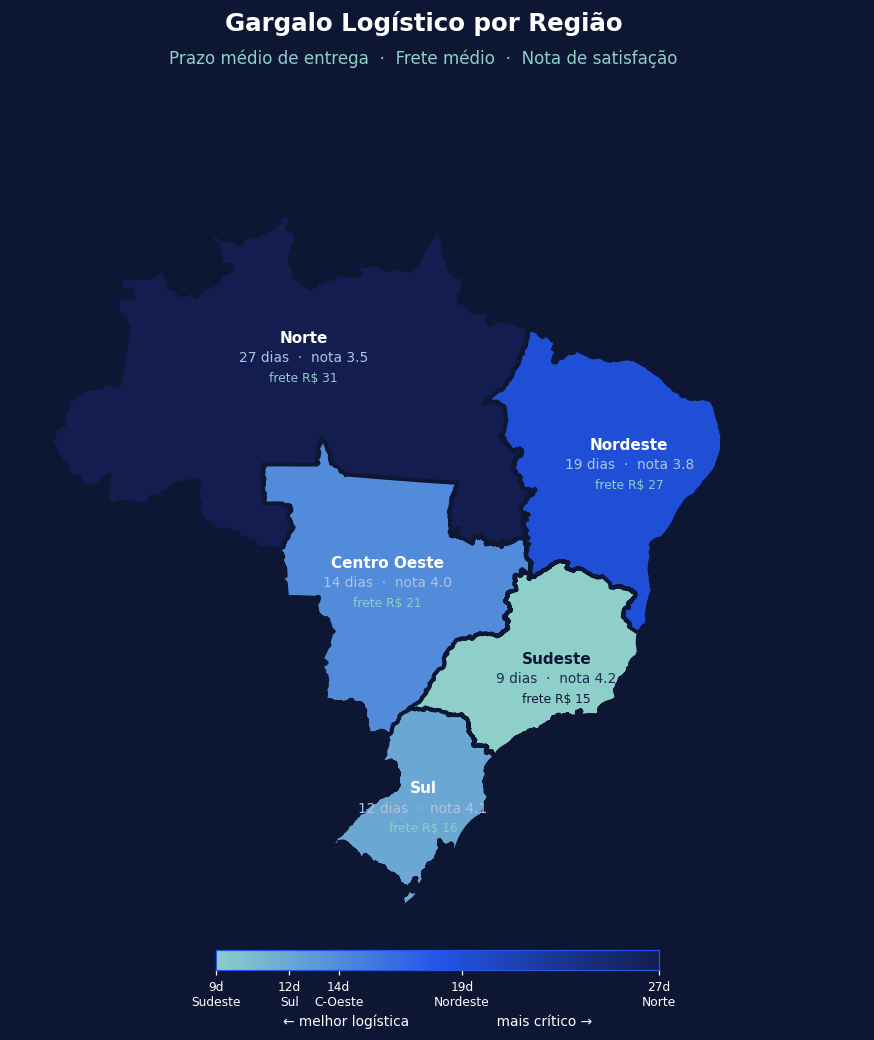

✅ Mapa salvo: mapa_logistica_olist.png


In [22]:
# ============================================================
# SLIDE 7 — Gargalo Logístico | Mapa por Região (Olist)
# ============================================================

!pip install geobr --quiet

import geobr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

# ── Dados regionais ──────────────────────────────────────────
dados = {
    'Norte':        {'prazo': 27, 'frete': 31, 'nota': 3.5},
    'Nordeste':     {'prazo': 19, 'frete': 27, 'nota': 3.8},
    'Centro Oeste': {'prazo': 14, 'frete': 21, 'nota': 4.0},
    'Sul':          {'prazo': 12, 'frete': 16, 'nota': 4.1},
    'Sudeste':      {'prazo':  9, 'frete': 15, 'nota': 4.2},
}

# ── Shapefile ────────────────────────────────────────────────
regioes = geobr.read_region(year=2020)
regioes['regiao'] = regioes['name_region'].str.replace('-', ' ').str.strip()
regioes['prazo']  = regioes['regiao'].map({k: v['prazo'] for k, v in dados.items()})
regioes['nota']   = regioes['regiao'].map({k: v['nota']  for k, v in dados.items()})
regioes['frete']  = regioes['regiao'].map({k: v['frete'] for k, v in dados.items()})

# ── Paleta Olist ─────────────────────────────────────────────
CMAP = LinearSegmentedColormap.from_list('olist', ['#8ECFC9', '#2255E8', '#131D4F'])
BG   = '#0D1633'

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

regioes.plot(
    column='prazo', cmap=CMAP, vmin=9, vmax=27,
    ax=ax, edgecolor=BG, linewidth=2.5, legend=False
)

# ── Labels ────────────────────────────────────────────────────
offsets = {
    'Norte':        ( 0.0,  2.0),
    'Nordeste':     ( 1.5,  0.0),
    'Centro Oeste': ( 0.0,  0.0),
    'Sul':          ( 0.0, -0.5),
    'Sudeste':      ( 1.0, -1.0),
}

TEXTO_ESCURO = {'Sudeste'}

for _, row in regioes.iterrows():
    nome = row['regiao']
    if nome not in dados: continue
    d = dados[nome]
    ox, oy = offsets.get(nome, (0, 0))
    cx = row.geometry.centroid.x + ox
    cy = row.geometry.centroid.y + oy

    escuro = nome in TEXTO_ESCURO
    c1 = '#0D1633' if escuro else 'white'
    c2 = '#1A3050' if escuro else '#B0C4DE'
    c3 = '#0D1633' if escuro else '#8ECFC9'

    ax.text(cx, cy + 0.7, nome,       ha='center', fontsize=10, fontweight='bold', color=c1)
    ax.text(cx, cy - 0.4, f"{d['prazo']} dias  ·  nota {d['nota']}", ha='center', fontsize=9, color=c2)
    ax.text(cx, cy - 1.5, f"frete R$ {d['frete']}",                  ha='center', fontsize=8, color=c3)

# ── Título ────────────────────────────────────────────────────
fig.text(0.5, 0.97, 'Gargalo Logístico por Região',
         ha='center', fontsize=16, fontweight='bold', color='white')
fig.text(0.5, 0.94, 'Prazo médio de entrega  ·  Frete médio  ·  Nota de satisfação',
         ha='center', fontsize=11, color='#8ECFC9')

# ── Barra de cores ────────────────────────────────────────────
sm = ScalarMappable(cmap=CMAP, norm=Normalize(vmin=9, vmax=27))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.032, pad=0.01, shrink=0.52, aspect=22)
cbar.set_ticks([9, 12, 14, 19, 27])
cbar.set_ticklabels(['9d\nSudeste', '12d\nSul', '14d\nC-Oeste', '19d\nNordeste', '27d\nNorte'])
cbar.set_label('← melhor logística                    mais crítico →',
               color='white', fontsize=9)
cbar.ax.tick_params(colors='white', labelsize=8)
cbar.outline.set_edgecolor('#2255E8')

ax.axis('off')
plt.savefig('mapa_logistica_olist.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Mapa salvo: mapa_logistica_olist.png")

---
## 11. Conclusões e Recomendações

### 11.1 Principais Achados

**📈 Crescimento robusto com projeção de R\$ 22,1M até 2023**
A Olist cresceu de 312 pedidos em 2016 para R\$ 8,6M de receita em 2018, com CAGR de 20,6% ao ano. Mantida essa taxa, a projeção aponta para R\$ 22,1M em 2023 — e ações de fidelização podem gerar R\$ 3,2M adicionais acumulados no período, sem custo de aquisição de novos clientes.

**📍 Concentração geográfica como risco e oportunidade**
SP+RJ+MG respondem por 66,5% dos clientes e concentram 75% dos sellers. O Nordeste, com 14% dos clientes, tem apenas 6% dos vendedores — desequilíbrio que explica o prazo de entrega 3x maior e a taxa de atraso de até 23,9% em estados como AL.

**🚚 Logística como gargalo crítico fora do Sudeste**
Pedidos com nota 1 têm atraso em 36,7% dos casos — 19x mais que pedidos com nota 5. Estados do Norte e Nordeste concentram os piores indicadores logísticos, não por falta de demanda, mas pela ausência de sellers e infraestrutura local.

**🔁  Taxa de recompra de 3,1% — o maior vazamento de valor**
96,9% dos clientes compraram apenas uma vez. Há 36.083 clientes "quentes" — compraram nos últimos 6 meses e não retornaram. Converter 10% desse pool por ano gera R$ 318 mil de receita incremental anual, crescendo junto com a base. Um cliente que compra 2x gasta em média 1,7x mais que um cliente de primeira compra.

**⭐ Qualidade do anúncio como causa raiz de insatisfação**
60% das notas 1 em Cama/Mesa/Banho não têm relação com atraso — produto diferente da foto ~25% e entrega incompleta ~35% são as causas mais frequentes. O problema é de governança de catálogo, não de logística.

**🤝 Ecossistema de vendedores com concentração moderada**
Minoria dos sellers gera 80% da receita, com concentração em SP. Sellers diversificados (mais de 5 categorias) mostram maior resiliência operacional. A expansão geográfica de sellers é a alavanca com maior impacto simultâneo em prazo, satisfação e receita regional.

---

### 11.2 Recomendações

| Prioridade | Ação | Impacto Esperado |
|---|---|---|
| 🔴 Alta | Programa de qualidade de anúncios em Cama/Mesa/Banho | Redução de até 60% das notas 1 na principal categoria |
| 🔴 Alta | Ajuste do prazo estimado por origem do seller | Redução imediata da percepção de atraso sem custo logístico |
| 🟡 Média | Programa de fidelização — CRM, cashback, reativação | R$ 3,2M incremental acumulado em 5 anos (cenário base) |
| 🟡 Média | Recrutamento de sellers no Norte e Nordeste | Redução do prazo regional de 24 → ~14 dias; atraso de 23% → ~10% |
| 🟢 Baixa | Curadoria de categorias de alto ticket (Computadores, Eletrodomésticos) | Elevação do ticket médio de R\$ 89 sem aumento proporcional de volume |

---

### 11.3 Limitações da Análise

- **Corte temporal:** O dataset encerra em agosto/2018, período de possível sazonalidade atípica
- **Produtos anonimizados:** Análises feitas por categoria — não é possível identificar SKUs específicos
- **Ausência de dados de custo:** Não há informações de margem, custo de aquisição ou custo logístico
- **Dados de 2016 incompletos:** Apenas 4 meses disponíveis, tornando comparações YoY menos precisas

---
*Análise desenvolvida por Juliana Brito | POSTECH DTAT | Tech Challenge — Fase 1*